### Data Circle Sprint 2
### Feature Engineering and Model Training Part 1
### Stack Overflow Buddies

Please refer to our slide deck for approach and results.

In [24]:
# Import the data manipulation and visualization libraries, as well as the machine learning tools from scikit-learn.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, KFold, cross_val_predict, cross_validate
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error, mean_squared_error
from catboost import CatBoostRegressor
from sklearn.linear_model import HuberRegressor
import re
import os

import warnings
 
import lightgbm as lgb
 
warnings.filterwarnings("ignore")

from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import OrdinalEncoder, RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer
import lightgbm as lgb
from xgboost import XGBRegressor
from sklearn.linear_model import ElasticNet


In [25]:
DATA_PATH = "./data/survey_results_public.csv" # Path to the dataset. Adjust this path if your dataset is located elsewhere.

In [26]:
DACH_COUNTRIES = ["Germany", "Austria", "Switzerland"] # List of DACH countries to filter the dataset by.

BRANCH_DEVELOPERS = "I am a developer by profession" # Filter for responders who are developers by profession.

SALARY_MIN = 15_000 # Minimum salary threshold. Salaries below this value will be considered outliers and removed from the dataset.
SALARY_MAX = 400_000 # Maximum salary threshold. Salaries above this value will be considered outliers and removed from the dataset.

NON_WORK_YEARS = 15 # Work experience cannot be more than responder's age minus NON_WORK_YEARS. This aims to filter out unrealistic work experience values.
NON_CODER_AGE = 7 # Minimum age for a responder to start coding. Responders that codes longer than age minus NON_CODER_AGE will be considered outliers.

RANDOM_STATE = 42 
N_SPLITS = 5 # Number of splits for K-Fold cross-validation.

# IQR multiplier for salary outlier filtering. 
OUTLIER_IQR_MULT = 1.5

# List of columns to drop from the dataset. Commented columns will not be dropped.
DROP_COLS = ['ResponseId', 'MainBranch', 
             #'Age', 'EdLevel', 'Employment', 
             'EmploymentAddl', 
             #'WorkExp', 'LearnCodeChoose', 
             'LearnCode', 
             #'LearnCodeAI', 
             'AILearnHow', 
             #'YearsCode', 'DevType', 'OrgSize', 'ICorPM', 'RemoteWork', 'PurchaseInfluence', 
             'TechEndorseIntro', 'TechEndorse_1', 'TechEndorse_2', 'TechEndorse_3', 'TechEndorse_4', 'TechEndorse_5', 'TechEndorse_6', 
             'TechEndorse_7', 'TechEndorse_8', 'TechEndorse_9', 'TechEndorse_13', 'TechEndorse_13_TEXT', 
             'TechOppose_1', 'TechOppose_2', 'TechOppose_3', 'TechOppose_5', 'TechOppose_7', 'TechOppose_9',
            'TechOppose_11', 'TechOppose_13', 'TechOppose_16', 'TechOppose_15', 'TechOppose_15_TEXT', 
            #'Industry', 
            'JobSatPoints_1', 'JobSatPoints_2', 'JobSatPoints_3', 'JobSatPoints_4', 'JobSatPoints_5', 
            'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10', 'JobSatPoints_11', 
            'JobSatPoints_13', 'JobSatPoints_14', 'JobSatPoints_15', 'JobSatPoints_16', 'JobSatPoints_15_TEXT', 
            # 'AIThreat', 
            'NewRole', 
            #'ToolCountWork', 'ToolCountPersonal', 'Country', 
            'Currency', 'CompTotal', 
            #'LanguageChoice', 'LanguageHaveWorkedWith', 
            'LanguageWantToWorkWith', 'LanguageAdmired', 
            #'LanguagesHaveEntry', 
            'LanguagesWantEntry', 
            #'DatabaseChoice', 'DatabaseHaveWorkedWith', 
            'DatabaseWantToWorkWith', 'DatabaseAdmired', 
            #'DatabaseHaveEntry', 
            'DatabaseWantEntry', 
            #'PlatformChoice', 'PlatformHaveWorkedWith', 
            'PlatformWantToWorkWith', 'PlatformAdmired', 
            #'PlatformHaveEntry', 
            'PlatformWantEntry', 
            #'WebframeChoice', 'WebframeHaveWorkedWith', 
            'WebframeWantToWorkWith', 'WebframeAdmired', 
            #'WebframeHaveEntry', 
            'WebframeWantEntry',
            #'DevEnvsChoice', 'DevEnvsHaveWorkedWith', 
            'DevEnvsWantToWorkWith', 'DevEnvsAdmired',
            #'DevEnvHaveEntry', 
            'DevEnvWantEntry', 'SOTagsHaveWorkedWith', 'SOTagsWantToWorkWith', 'SOTagsAdmired', 'SOTagsHaveEntry', 'SOTagsWant Entry', 'OpSysPersonal use', 
            #'OpSysProfessional use', 
            'OfficeStackAsyncHaveWorkedWith', 'OfficeStackAsyncWantToWorkWith', 'OfficeStackAsyncAdmired', 'OfficeStackHaveEntry', 'OfficeStackWantEntry', 
            'CommPlatformHaveWorkedWith', 'CommPlatformWantToWorkWith', 'CommPlatformAdmired', 'CommPlatformHaveEntr', 'CommPlatformWantEntr', 
            #'AIModelsChoice', 'AIModelsHaveWorkedWith', 
            'AIModelsWantToWorkWith', 'AIModelsAdmired', 
            #'AIModelsHaveEntry', 
            'AIModelsWantEntry', 'SOAccount', 'SOVisitFreq', 'SODuration', 'SOPartFreq', 'SO_Dev_Content', 
            'SO_Actions_1', 'SO_Actions_16', 'SO_Actions_3', 'SO_Actions_4', 'SO_Actions_5', 'SO_Actions_6', 'SO_Actions_9', 'SO_Actions_7', 
            'SO_Actions_10', 'SO_Actions_15', 'SO_Actions_15_TEXT', 'SOComm', 'SOFriction', 
            #'AISelect', 
            'AISent', 'AIAcc', 
            #'AIComplex', 'AIToolCurrently partially AI', 
            "AIToolDon't plan to use AI for this task", 'AIToolPlan to partially use AI', 'AIToolPlan to mostly use AI', 
            #'AIToolCurrently mostly AI', 
            'AIFrustration', 'AIExplain', 
            #'AIAgents', 
            'AIAgentChange', 'AIAgent_Uses', 'AgentUsesGeneral', 
            'AIAgentImpactSomewhat agree', 'AIAgentImpactNeutral', 'AIAgentImpactSomewhat disagree', 'AIAgentImpactStrongly agree', 'AIAgentImpactStrongly disagree', 
            'AIAgentChallengesNeutral', 'AIAgentChallengesSomewhat disagree', 'AIAgentChallengesStrongly agree', 'AIAgentChallengesSomewhat agree', 'AIAgentChallengesStrongly disagree', 
            # 'AIAgentKnowledge', 'AIAgentKnowWrite', 'AIAgentOrchestration', 'AIAgentOrchWrite', 'AIAgentObserveSecure', 
            #'AIAgentObsWrite', 'AIAgentExternal', 'AIAgentExtWrite', 
            'AIHuman', 'AIOpen', 
            #'ConvertedCompYearly', 'JobSat'
            ] 

# Top-N most common values to keep for high-cardinality multi-select fields.
# Everything else gets folded into "other" via the binarizer ignoring it.
TOP_N_LANGUAGES   = 25
TOP_N_DATABASES   = 15
TOP_N_PLATFORMS   = 12
TOP_N_WEBFRAMES   = 20
TOP_N_IDES        = 15
TOP_N_AIMODELS    = 15
TOP_N_OS          = 8
TOP_N_EMPLOYMENT  = 8
TOP_N_LEARN       = 10



# List of categorical columns.
CATEGORICAL_COLS = [
    "Country", "EdLevel", "DevType", "OrgSize", "ICorPM", "RemoteWork",
    "PurchaseInfluence", "Industry", "AIThreat",
    "LanguageChoice", "DatabaseChoice", "PlatformChoice", "WebframeChoice",
    "DevEnvsChoice", "AIModelsChoice",
    "AISelect", "AIComplex", "AIAgents",
    "AIAgentKnowledge", "AIAgentOrchestration",
    "AIAgentObserveSecure", "AIAgentExternal",
]

# List of yes/no columns to be mapped to 1/0.
YES_NO_COLS = ["LearnCodeAI", "LearnCodeChoose", "PurchaseInfluence", "DatabaseChoice", "PlatformChoice", "WebframeChoice", "DevEnvsChoice", 
               "AIModelsChoice", "SOAccount", "SOComm", "AISelect", "AIExplain", "AIAgents", "AIAgentChange", "LearnAI"]

# Multi-select (semicolon-separated) → multi-hot encoded with top-N
MULTI_SELECT_SPECS = [
    (["LanguageHaveWorkedWith", "LanguagesHaveEntry"], "lang",    TOP_N_LANGUAGES),
    (["DatabaseHaveWorkedWith", "DatabaseHaveEntry"],  "db",      TOP_N_DATABASES),
    (["PlatformHaveWorkedWith", "PlatformHaveEntry"],  "plat",    TOP_N_PLATFORMS),
    (["WebframeHaveWorkedWith", "WebframeHaveEntry"],  "web",     TOP_N_WEBFRAMES),
    (["DevEnvsHaveWorkedWith",  "DevEnvHaveEntry"],    "ide",     TOP_N_IDES),
    (["AIModelsHaveWorkedWith", "AIModelsHaveEntry"],  "aimodel", TOP_N_AIMODELS),
    (["OpSysProfessional use"],                        "os",      TOP_N_OS),
    (["Employment"],                                   "emp",     TOP_N_EMPLOYMENT),
]

# Grouped languages with frequency more than 5
LANGUAGE_GROUPS = {
    # Web frontend trio
    "web_frontend":   ["JavaScript", "TypeScript", "HTML/CSS"],

    # Data / scientific computing
    "data_science":   ["Python", "R", "MATLAB"],

    # Shell + query glue (sysadmin / DBA signal)
    "query_shell":    ["SQL", "Bash/Shell (all shells)", "PowerShell"],

    # JVM ecosystem
    "jvm":            ["Java", "Kotlin", "Scala", "Groovy", "Clojure"],

    # .NET ecosystem
    "dotnet":         ["C#", "F#", "Visual Basic (.NET)", "VBA"],

    # Systems / low-level
    "systems":        ["C", "C++", "Rust", "Zig", "Assembly"],

    # Modern backend (PHP/Ruby legacy + Go/Elixir/Erlang modern)
    "web_backend":    ["PHP", "Ruby", "Go", "Elixir", "Erlang"],

    # Mobile native
    "mobile":         ["Swift", "Objective-C", "Dart"],
}

# Grouped databases with frequency more than 5
DATABASE_GROUPS = {
    # Traditional relational SQL — the workhorses
    "sql_relational": [
        "PostgreSQL", "MySQL", "MariaDB", "SQLite",
        "Microsoft SQL Server", "Oracle", "IBM DB2",
        "Microsoft Access", "H2", "Firebird",
    ],

    # Cloud warehouses + distributed SQL
    "sql_cloud_warehouse": [
        "BigQuery", "Snowflake", "Amazon Redshift", "Databricks SQL",
        "Cockroachdb", "SAP HANA",
    ],

    # NoSQL document stores + BaaS DBs
    "nosql_document": [
        "MongoDB", "Dynamodb", "Cosmos DB",
        "Cloud Firestore", "Firebase Realtime Database",
        "Couchdb", "Pocketbase", "Supabase", "RavenDB",
    ],

    # Key-value / caches
    "kv_cache": ["Redis", "Valkey"],

    # Search + columnar analytics
    "search_analytics": ["Elasticsearch", "Clickhouse", "DuckDB", "Meilisearch"],

    # Specialty NoSQL — time-series, graph, wide-column
    "nosql_specialty": ["InfluxDB", "Neo4J", "Cassandra"],
}

# Grouped platforms with frequency more than 5
PLATFORM_GROUPS = {
    # Big-3 hyperscalers
    "hyperscaler_cloud": [
        "Amazon Web Services (AWS)", "Microsoft Azure", "Google Cloud",
    ],

    # Other cloud + PaaS + BaaS
    "other_cloud": [
        "Cloudflare", "Digital Ocean", "IBM Cloud",
        "Heroku", "Railway", "Vercel", "Netlify",
        "Firebase", "Supabase",
    ],

    # Containers / Kubernetes
    "containers": [
        "Docker", "Kubernetes", "Podman",
    ],

    # Infrastructure as Code + config management
    "iac": [
        "Ansible", "Terraform", "Pulumi",
    ],

    # Observability / monitoring
    "observability": [
        "Datadog", "New Relic", "Prometheus", "Splunk",
    ],

    # Build tools (compiled languages + JS bundlers)
    "build_tools": [
        "Make", "CMake", "Gradle", "Maven (build tool)", "MSBuild", "Ninja",
        "Cargo", "Vite", "Webpack", "Bun",
    ],

    # Language-level package managers
    "pkgmgr_lang": [
        "npm", "Yarn", "pnpm", "Pip", "Poetry", "uv",
        "NuGet", "Composer",
    ],

    # OS-level package managers
    "pkgmgr_os": [
        "APT", "Pacman", "Homebrew", "Chocolatey", "Nix",
    ],
}

# Grouped web frameworks with frequency more than 5
WEBFRAME_GROUPS = {
    # All JS UI frameworks — modern + legacy together
    "js_frontend": ["React", "Angular", "Vue.js", "Svelte", "Astro",
                    "SolidJS", "SvelteKit", "AngularJS", "jQuery"],

    # JS server-side / meta-frameworks
    "js_backend":  ["Node.js", "Express", "NestJS", "Fastify",
                    "Next.js", "Nuxt.js", "Deno"],

    # Python (web + data apps together)
    "python_web":  ["Django", "Flask", "FastAPI", "Streamlit"],

    # JVM (modern + legacy together)
    "jvm_web":     ["Spring Boot", "Quarkus", "Vaadin"],

    # .NET
    "dotnet_web":  ["ASP.NET", "ASP.NET Core", "Blazor"],

    # PHP (frameworks + CMSes together)
    "php_web":     ["Laravel", "Symfony", "WordPress", "Drupal", "TYPO3"],

    # Rust web
    "rust_web":    ["Axum", "Actix", "Dioxus", "Leptos"],
}

# Grouped IDEs with frequency more than 5
IDE_GROUPS = {
    # Modern general-purpose editors (VS Code dominant; Cursor goes in ai_editor instead)
    "modern_general":  ["Visual Studio Code", "VSCodium", "Zed", "Sublime Text"],

    # AI-assisted editors (early-adopter / productivity signal)
    "ai_editor":       ["Cursor", "Claude Code", "Windsurf",
                        "Cline and/or Roo", "Aider", "Bolt",
                        "Lovable.dev", "Trae"],

    # JetBrains IDE family (paid, enterprise signal — incl. Android Studio)
    "jetbrains":       ["IntelliJ IDEA", "PyCharm", "WebStorm", "Rider",
                        "PhpStorm", "RustRover", "Android Studio"],

    # Terminal editors with vi keybindings (power-user / senior signal)
    "vim_family":      ["Vim", "Neovim"],

    # Platform-locked heavyweight IDEs (each forces a specific stack/OS)
    "platform_ide":    ["Visual Studio", "Xcode", "Eclipse"],

    # Notebooks (data-scientist signal)
    "notebook":        ["Jupyter Notebook/JupyterLab"],

    # Lightweight quick-edit tools (Windows admins, casual coders)
    "lightweight":     ["Notepad++", "Nano"],
}

# Grouped AI models with frequency more than 5
MODEL_GROUPS = {
    # OpenAI ecosystem
    "openai": [
        "OpenAI GPT (chatbot models)",
        "OpenAI reasoning models",
        "OpenAI image generating models",
    ],

    # Google Gemini ecosystem
    "gemini": [
        "Gemini Flash (general purpose models)",
        "Gemini Pro (reasoning models)",
    ],

    # Anthropic models
    "anthropic": [
        "Claude Sonnet",
    ],

    # DeepSeek ecosystem
    "deepseek": [
        "DeepSeek R (reasoning models)",
        "DeepSeek V (general purpose models)",
    ],

    # Meta open-weight models
    "meta": [
        "Meta Llama (all models)",
    ],

    # Mistral AI
    "mistral": [
        "Mistral AI models",
    ],

    # Perplexity
    "perplexity": [
        "Perplexity Sonar models",
    ],

    # xAI
    "xai": [
        "x Grok models",
    ],

    # Alibaba ecosystem
    "alibaba": [
        "Alibaba Cloud Qwen models",
    ],

    # Microsoft small models
    "microsoft": [
        "Microsoft Phi-4 models",
    ],

    # Amazon foundation models
    "amazon": [
        "Amazon Titan models",
    ],
}

# List of groups for multi-select fields. Each group maps a column prefix to a set of related values. IF YOU WANT TOP-N BINARIZATION, MAKE SURE COMMENT THIS OUT.
GROUPS_BY_PREFIX = {
   # "lang": LANGUAGE_GROUPS,
   # "db":   DATABASE_GROUPS,
   # "plat": PLATFORM_GROUPS,
  # "webframe": WEBFRAME_GROUPS,
  #  "ide": IDE_GROUPS,
  #  "model": MODEL_GROUPS,
}

SALARY_COL = "ConvertedCompYearly" # Target variable for prediction.
START_FEATURES = 5 # Initial number of features to start with in the feature selection process.
MAX_FEATURES = 150 # Maximum number of features to select in the feature selection process.

In [27]:
def load_dach(path) -> pd.DataFrame:

    """Loads the dataset, filters for DACH countries, and applies basic cleaning steps like removing rows without salary or with implausible salary values."""

    # Load the dataset from the specified path.
    df = pd.read_csv(path)
    print(f"Loaded {len(df):,} total responses")

    # Filter the dataset to include only respondents from DACH countries who are developers by profession.
    df = df[(df["Country"].isin(DACH_COUNTRIES)) & (df['MainBranch'] == BRANCH_DEVELOPERS)].copy()
    print(f"DACH subset: {len(df):,} responses")
    print(df["Country"].value_counts().to_string())

    # Drop rows without salary or with implausible values.
    df = df.dropna(subset=["ConvertedCompYearly"])
    df = df[df["ConvertedCompYearly"].between(SALARY_MIN, SALARY_MAX)]
    print(f"After salary range filter: {len(df):,} responses")

    # Drop columns that are not needed for modeling.
    df = df.drop(columns=DROP_COLS)
    print(f"After column drop: {len(df.columns):,} columns")
    return df.reset_index(drop=True)

In [28]:
def parse_age_upper(value) -> float:
    
    """Convert age brackets to the upper bound as a number.
    Example: "25-34 years old" → 34."""

    s = str(value).strip().lower()

    if "prefer not" in s:
        return np.nan
    
    # Pull all integers out of the string, take the largest one.
    nums = [int(n) for n in re.findall(r"\d+", s)]
    if not nums:
        return np.nan
    return float(max(nums))

In [29]:
def clean_outliers(df: pd.DataFrame) -> pd.DataFrame:
    
    """Per-country IQR filtering on log-salary + experience sanity checks. """

    n_in = len(df)
    print(f"\nOutlier cleaning starting from {n_in:,} responses:")

    # Per-country IQR on log salary.
    log_sal = np.log1p(df["ConvertedCompYearly"])
    keep = pd.Series(True, index=df.index)
    for country in DACH_COUNTRIES:
        mask = (df["Country"] == country).values
        if mask.sum() == 0:
            continue
        q1, q3 = log_sal[mask].quantile([0.25, 0.75])
        iqr = q3 - q1
        lo = q1 - OUTLIER_IQR_MULT * iqr
        hi = q3 + OUTLIER_IQR_MULT * iqr
        outlier_mask = mask & ((log_sal < lo) | (log_sal > hi)).values
        n_dropped = int(outlier_mask.sum())
        keep &= ~outlier_mask
        # Convert log bounds back to USD for the printout.
        print(
            f"  {country:14s}: kept ${np.expm1(lo):>7,.0f}–${np.expm1(hi):>7,.0f}  "
            f"(removed {n_dropped} of {int(mask.sum())})"
        )
    df = df[keep]

    # Add AgeUpper column for the experience sanity check.
    df["AgeUpper"] = df["Age"].apply(parse_age_upper)

    # Experience sanity check. 
    max_exp = df["AgeUpper"] - NON_WORK_YEARS
    df["WorkExp"] = pd.to_numeric(df["WorkExp"], errors="coerce").clip(lower=0, upper=max_exp)

    max_coding_years = df["AgeUpper"] - NON_CODER_AGE
    df["YearsCode"] = pd.to_numeric(df["YearsCode"], errors="coerce").clip(lower=0, upper=max_coding_years)

    df = df.drop(columns=['AgeUpper'], errors="ignore")
    return df.reset_index(drop=True)



In [30]:
def parse_multiselect(value) -> list[str]:

    """Parse a semicolon-separated multi-select field into a list of strings, handling NaN values."""

    if pd.isna(value):
        return []
    return [v.strip() for v in str(value).split(";") if v.strip()]

In [31]:
 
def top_n_binarizer(series: pd.Series, n: int | None) -> tuple[MultiLabelBinarizer, np.ndarray]:
    """Fit a MultiLabelBinarizer. If we use TOP_N technologies - n will be the number of top technologies to include. If n is None, use all distinct classes for grouping."""
    parsed = series.apply(parse_multiselect)
    counts: dict[str, int] = {}
    for items in parsed:
        for item in items:
            counts[item] = counts.get(item, 0) + 1
    sorted_classes = [k for k, _ in sorted(counts.items(), key=lambda kv: -kv[1])]
    top = sorted_classes if n is None else sorted_classes[:n]

    mlb = MultiLabelBinarizer(classes=top)
    parsed_filtered = parsed.apply(lambda items: [i for i in items if i in top])
    matrix = mlb.fit_transform(parsed_filtered)
    return mlb, matrix

In [32]:
def yes_no_binarizer(series: pd.Series) -> np.ndarray:
    """Convert strings containing 'yes' to 1, otherwise 0. NaN -> 0."""
    return (
        series.fillna("")
        .astype(str)
        .str.lower()
        .str.contains("yes")
        .astype(int)
        .values
    )

In [33]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    feats = pd.DataFrame(index=df.index)

    # Yes/No columns
    for col in YES_NO_COLS:
        if col in df.columns:
            feats[col] = yes_no_binarizer(df[col])

    # Simple categorical columns
    for col in CATEGORICAL_COLS:
        if col in df.columns:
            feats[col] = df[col].astype("object")

    # Multi-select columns — either grouped OR top-N, never both
    for sources, prefix, n in MULTI_SELECT_SPECS:
        available = [c for c in sources if c in df.columns]
        if not available:
            print(f"  warning: no columns from {sources}, skipping")
            continue
        
        combined = df[available[0]].fillna("").astype(str)
        for c in available[1:]:
            combined = combined + ";" + df[c].fillna("").astype(str)
        
        groups = GROUPS_BY_PREFIX.get(prefix)

        # If groups are defined for this prefix, use them to create group features. Otherwise, do top-N binarization.
        if groups is not None:
            mlb, matrix = top_n_binarizer(combined, None)
            classes_lc = [str(c).lower() for c in mlb.classes_]
            grouped_indices: set[int] = set()

            for group_name, members in groups.items():
                members_lc = {m.lower() for m in members}
                acc = np.zeros(matrix.shape[0], dtype=int)
                for j, cls_lc in enumerate(classes_lc):
                    if cls_lc in members_lc:
                        acc |= matrix[:, j]
                        grouped_indices.add(j)
                feats[f"{prefix}_group_{group_name}"] = acc

            # Everything not in any group → one "other" feature
            other_acc = np.zeros(matrix.shape[0], dtype=int)
            for j in range(len(mlb.classes_)):
                if j not in grouped_indices:
                    other_acc |= matrix[:, j]
            feats[f"{prefix}_group_other"] = other_acc
            
        else:
            # No groups defined, just do top-N binarization as usual.
            mlb, matrix = top_n_binarizer(combined, n)
            for j, cls in enumerate(mlb.classes_):
                safe = (str(cls).strip()
                    .replace(" ", "_").replace("/", "_")
                    .replace(",", "").replace(".", ""))
                feats[f"{prefix}_{safe}"] = matrix[:, j]

    print(f"Built features with {feats.shape[1]} columns")
    return feats

In [34]:
def make_preprocessor(feats: pd.DataFrame) -> ColumnTransformer:

    # Features to impute with the median (numerical)
    numerical_features = feats.select_dtypes(include="number").columns.tolist()

    # Features to impute with the mode and One-Hot Encode (categorical/ordinal)
    categorical_features = feats.select_dtypes(include="object").columns.tolist()

    # A. Numerical Pipeline: Impute with Median
    numerical_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
    ])

    # B. Categorical Pipeline: Impute with Mode, then One-Hot Encode
    categorical_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore')) 
    ])
 
    # C. Combine all steps using ColumnTransformer
    return ColumnTransformer(
        transformers=[
            ('num', numerical_pipeline, numerical_features),
            ('cat', categorical_pipeline, categorical_features)
        ],
        remainder='drop' # Drop all other columns
    )



In [35]:
def compute_mi_scores(feats: pd.DataFrame, y: pd.Series) -> pd.Series:
    """
    MI is computed only on the TRAIN split — no leakage from test rows.
    Categoricals are temporarily OrdinalEncoded just so sklearn accepts them;
    the discrete_features flag tells MI to treat them correctly.
    """
    X_mi = feats.copy()
    y_log = np.log1p(y)
 
    cat_cols = X_mi.select_dtypes(include=["object", "category"]).columns.tolist()
    num_cols = X_mi.select_dtypes(include="number").columns.tolist()
 
    if cat_cols:
        enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
        X_mi[cat_cols] = enc.fit_transform(X_mi[cat_cols].fillna("__missing__"))
 
    X_mi[num_cols] = X_mi[num_cols].fillna(X_mi[num_cols].median())
 
    discrete_mask = [col in cat_cols for col in X_mi.columns]
 
    mi = mutual_info_regression(
        X_mi, y_log,
        discrete_features=discrete_mask,
        random_state=RANDOM_STATE,
        n_neighbors=5,
    )
    return pd.Series(mi, index=X_mi.columns).sort_values(ascending=False)
 

In [36]:
METRIC_NAMES = ["RMSE", "MAE", "R2"]
 
def compute_all_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    RMSE          — penalises large errors heavily (sensitive to outliers)
    MAE           — average absolute error, same unit as salary (€)
    R²            — proportion of variance explained (1.0 = perfect)
    
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {"RMSE": rmse, "MAE": mae, "R2": r2, }
 
# CV scorers (subset — MedAE and ExplainedVar added manually below)
cv_scorers = {
    "RMSE": make_scorer(lambda yt, yp: np.sqrt(mean_squared_error(yt, yp)),
                        greater_is_better=False),
    "MAE":  make_scorer(mean_absolute_error,  greater_is_better=False),
    "R2":    make_scorer(r2_score),
}
 
def run_cv(pipeline: Pipeline, X: pd.DataFrame, y: pd.Series) -> dict:
    """Returns mean and std for each metric across CV folds."""
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    cv = cross_validate(pipeline, X, y, cv=kf,
                        scoring=cv_scorers, return_train_score=False)
    out = {}
    for name in METRIC_NAMES:
        raw = cv[f"test_{name}"]
        # flip sign for error metrics (sklearn negates them)
        if name not in ("R2", "ExplainedVar"):
            raw = -raw
        out[name]          = raw.mean()
        out[f"{name}_std"] = raw.std()
    return out
 
def run_test(pipeline: Pipeline,
             X_train: pd.DataFrame, y_train: pd.Series,
             X_test: pd.DataFrame,  y_test: pd.Series) -> dict:
    """Fit on full train set, evaluate on held-out test set."""
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    return compute_all_metrics(y_test.values, y_pred)

In [37]:
def build_model_pipeline(preprocessor: ColumnTransformer,
                         model_name: str) -> Pipeline:
    if model_name == "Ridge":
        return Pipeline([
            ("preprocessor", preprocessor),
            ("scaler",        StandardScaler(with_mean=False)),
            ("model",         Ridge(alpha=10.0)),
        ])
    if model_name == "RandomForest":
        return Pipeline([
            ("preprocessor", preprocessor),
            ("model", RandomForestRegressor(
                n_estimators=200, min_samples_leaf=5,
                n_jobs=-1, random_state=RANDOM_STATE,
            )),
        ])
    if model_name == "LightGBM":
        return Pipeline([
            ("preprocessor", preprocessor),
            ("model", lgb.LGBMRegressor(
                n_estimators=1000, learning_rate=0.05,
                num_leaves=63, subsample=0.8, colsample_bytree=0.8,
                min_child_samples=20, n_jobs=-1,
                random_state=RANDOM_STATE, verbose=-1,
            )),
        ])
    if model_name == "CatBoost":
        return Pipeline([
        ("preprocessor", preprocessor),
        ("model", CatBoostRegressor(
            iterations=1000,
            learning_rate=0.05,
            depth=6,
            random_seed=RANDOM_STATE,
            verbose=0,
        )),
    ])

    if model_name == "Huber":
        return Pipeline([
        ("preprocessor", preprocessor),
        ("scaler",        StandardScaler(with_mean=False)),
        ("model",         HuberRegressor(epsilon=1.35, max_iter=2000)),
    ])
    if model_name == "XGBoost":
        return Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=5,      # same role as min_child_samples in LightGBM
            tree_method="hist",      # fast, same algorithm as LightGBM under the hood
            n_jobs=-1,
            random_state=RANDOM_STATE,
            verbosity=0,
        )),
    ])

    if model_name == "ElasticNet":
        return Pipeline([
        ("preprocessor", preprocessor),
        ("scaler",        StandardScaler(with_mean=False)),
        ("model",         ElasticNet(
            alpha=1.0,
            l1_ratio=0.5,    # 0 = pure Ridge, 1 = pure Lasso, 0.5 = equal mix
            max_iter=2000,   # needs more iterations than default on OHE-expanded data
        )),
    ])
    raise ValueError(f"Unknown model: {model_name}")

 
 
MODEL_NAMES = ["Ridge", "RandomForest", "LightGBM", "CatBoost", "Huber", "XGBoost", "ElasticNet"]
 

In [38]:
def empty_store():
    store = {"n_features": []}
    for m in METRIC_NAMES:
        store[f"cv_{m}"]      = []
        store[f"cv_{m}_std"]  = []
        store[f"test_{m}"]    = []
    return store
 
def append_results(store: dict, n: int, cv_metrics: dict, test_metrics: dict):
    store["n_features"].append(n)
    for m in METRIC_NAMES:
        store[f"cv_{m}"].append(cv_metrics[m])
        store[f"cv_{m}_std"].append(cv_metrics[f"{m}_std"])
        store[f"test_{m}"].append(test_metrics[m])

In [39]:
def compute_spearman_scores(feats, y):
    from scipy.stats import spearmanr
    X_enc = feats.copy()
    cat_cols = X_enc.select_dtypes(include=["object","category"]).columns
    if len(cat_cols):
        enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
        X_enc[cat_cols] = enc.fit_transform(X_enc[cat_cols].fillna("__missing__"))
    X_enc = X_enc.fillna(X_enc.median())
    scores = {col: abs(spearmanr(X_enc[col], y).statistic) for col in X_enc.columns}
    return pd.Series(scores).sort_values(ascending=False)


In [40]:
def run_pipeline(df: pd.DataFrame):
    print(f"\n{'='*60}")
    print(f"Dataset shape : {df.shape}")
    print(f"Target        : {SALARY_COL}")
    print(f"Train/test    : {int(0.8*100)}% / {int(0.2*100)}%")
    print(f"Feature rounds: {START_FEATURES} → {MAX_FEATURES}")
    print(f"{'='*60}\n")
 
    y = df[SALARY_COL].copy()
 
    # Build features using YOUR function
    print("Building features...")
    feats = build_features(df)
 
    cat_cols = feats.select_dtypes(include=["object", "category"]).columns.tolist()
    num_cols = feats.select_dtypes(include="number").columns.tolist()
    print(f"Numeric features    : {len(num_cols)}")
    print(f"Categorical features: {len(cat_cols)}")
    print(f"Total features      : {feats.shape[1]}\n")
 
    # Train / test split — done ONCE, before MI scoring
    X_train, X_test, y_train, y_test = train_test_split(
        feats, y, test_size=0.2, random_state=RANDOM_STATE
    )
    print(f"Train rows: {len(X_train)}  |  Test rows: {len(X_test)}\n")
 
    # MI scores computed on TRAIN only — no leakage
    print("Computing Mutual Information scores (on train set)...")
    mi_scores = compute_mi_scores(X_train, y_train)
    spearman_score = compute_spearman_scores(X_train, y_train)
    print("Computing Spearman correlation scores (on train set)...")
    top_display = min(124, len(spearman_score))
    print(f"\nTop-{top_display} features by Spearman score:")
    print(spearman_score.head(top_display).to_string())
    print()
 
    max_n = min(MAX_FEATURES, len(mi_scores))
    results = {name: empty_store() for name in MODEL_NAMES}
 
    for n in range(START_FEATURES, max_n + 1):
        top_cols = mi_scores.head(n).index.tolist()
 
        X_tr_sub   = X_train[top_cols].copy()
        X_te_sub   = X_test[top_cols].copy()
        preprocessor = make_preprocessor(X_tr_sub)
 
        print(f"\nRound top-{n:02d} features")
        print(f"  {'Model':<14} {'CV RMSE':>12} {'CV R²':>8} {'Test RMSE':>12} {'Test R²':>8}")
        print(f"  {'-'*14} {'-'*12} {'-'*8} {'-'*12} {'-'*8} ")
 
        for model_name in MODEL_NAMES:
            # ── CV on train ──
            cv_pipe    = build_model_pipeline(preprocessor, model_name)
            cv_metrics = run_cv(cv_pipe, X_tr_sub, y_train)
 
            # ── Test evaluation (refit on full train) ──
            test_pipe    = build_model_pipeline(preprocessor, model_name)
            test_metrics = run_test(test_pipe, X_tr_sub, y_train, X_te_sub, y_test)
 
            append_results(results[model_name], n, cv_metrics, test_metrics)
 
            print(
                f"  {model_name:<14} "
                f"{cv_metrics['RMSE']:>12,.0f} "
                f"{cv_metrics['R2']:>8.3f} "
                f"{test_metrics['RMSE']:>12,.0f} "
                f"{test_metrics['R2']:>8.3f} "
                
            )
 
    return results, mi_scores

In [41]:
COLORS = {"Ridge": "#4e79a7", "RandomForest": "#f28e2b", "LightGBM": "#59a14f", "CatBoost": "#e15759", "Huber": "#76b7b2", "XGBoost": "#edc949", "ElasticNet": "#af7aa1"}
 
def plot_results(results: dict, output_dir: str = "."):
    """
    2 rows × 3 cols:
      Row 1 — CV metrics   (RMSE, R², MAE)
      Row 2 — Test metrics (RMSE, R², MAPE + MedAE)
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("DACH Salary Prediction — Incremental Feature Selection",
                 fontsize=14, fontweight="bold")
 
    plot_specs = [
        # (row, col, cv/test, metric, title, ylabel, lower_better)
        (0, 0, "cv",   "RMSE",        "CV RMSE",              "RMSE (€)",   True),
        (0, 1, "cv",   "R2",          "CV R²",                "R²",         False),
        (0, 2, "cv",   "MAE",         "CV MAE",               "MAE (€)",    True),
        (1, 0, "test", "RMSE",        "Test RMSE",            "RMSE (€)",   True),
        (1, 1, "test", "R2",          "Test R²",              "R²",         False),
    ]
 
    for row, col, split, metric, title, ylabel, lower in plot_specs:
        ax = axes[row][col]
        for model_name, data in results.items():
            n   = data["n_features"]
            col_color = COLORS[model_name]
            y_vals = data[f"{split}_{metric}"]
 
            ax.plot(n, y_vals, marker="o", label=model_name,
                    color=col_color, linewidth=2)
 
            # Add std band only for CV metrics
            if split == "cv":
                std = data[f"cv_{metric}_std"]
                ax.fill_between(
                    n,
                    np.array(y_vals) - np.array(std),
                    np.array(y_vals) + np.array(std),
                    alpha=0.15, color=col_color,
                )

 
        direction = "↓ better" if lower else "↑ better"
        ax.set_title(f"{title}  ({direction})", fontsize=11)
        ax.set_xlabel("Number of top features")
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
 
        if metric in ("RMSE", "MAE"):
            ax.yaxis.set_major_formatter(
                mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
 
    plt.tight_layout()
    out_path = os.path.join(output_dir, "feature_selection_results.png")
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"\nPlot saved → {out_path}")
    plt.show()

In [42]:
def plot_mi_scores(mi_scores: pd.Series, top_n: int = 20, output_dir: str = "."):
    fig, ax = plt.subplots(figsize=(8, 6))
    top    = mi_scores.head(top_n)
    colors = plt.cm.viridis(np.linspace(0.8, 0.2, len(top)))
    ax.barh(top.index[::-1], top.values[::-1], color=colors[::-1])
    ax.set_title(f"Top-{top_n} Features by Mutual Information Score",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("MI Score")
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    out_path = os.path.join(output_dir, "mi_scores.png")
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Plot saved → {out_path}")
    plt.show()
 

In [43]:
def print_summary(results: dict):
    print(f"\n{'='*70}")
    print("BEST RESULT PER MODEL  (by test R²)")
    print(f"{'='*70}")
    header = f"{'Model':<14} {'N':>4} {'CV R²':>7} {'Test R²':>8} {'Test RMSE':>12} {'Test MAE':>10} {'Test MAPE%':>10} {'Test MedAE':>12}"
    print(header)
    print("-" * len(header))
    for model_name, data in results.items():
        best = int(np.argmax(data["test_R2"]))
        n    = data["n_features"][best]
        print(
            f"{model_name:<14} {n:>4} "
            f"{data['cv_R2'][best]:>7.3f} "
            f"{data['test_R2'][best]:>8.3f} "
            f"{data['test_RMSE'][best]:>12,.0f} "
            f"{data['test_MAE'][best]:>10,.0f} "
        )
 
    # Full table → CSV
    rows = []
    for model_name, data in results.items():
        for i, n in enumerate(data["n_features"]):
            rows.append({
                "Model":           model_name,
                "N_features":      n,
                "CV_RMSE":         round(data["cv_RMSE"][i], 0),
                "CV_MAE":          round(data["cv_MAE"][i], 0),
                "CV_R2":           round(data["cv_R2"][i], 4),
                "Test_RMSE":       round(data["test_RMSE"][i], 0),
                "Test_MAE":        round(data["test_MAE"][i], 0),
                "Test_R2":         round(data["test_R2"][i], 4),
            })
    df_summary = pd.DataFrame(rows)
    out_path = os.path.join(".", "results_summary.csv")
    df_summary.to_csv(out_path, index=False)
    print(f"\nFull results saved → {out_path}")

Loaded 49,191 total responses
DACH subset: 3,056 responses
Country
Germany        2322
Switzerland     415
Austria         319
After salary range filter: 2,247 responses
After column drop: 51 columns

Outlier cleaning starting from 2,247 responses:
  Germany       : kept $ 30,483–$218,561  (removed 95 of 1699)
  Austria       : kept $ 27,223–$213,462  (removed 7 of 222)
  Switzerland   : kept $ 69,535–$283,559  (removed 27 of 326)

Dataset shape : (2118, 51)
Target        : ConvertedCompYearly
Train/test    : 80% / 20%
Feature rounds: 5 → 150

Building features...
Built features with 140 columns
Numeric features    : 118
Categorical features: 22
Total features      : 140

Train rows: 1694  |  Test rows: 424

Computing Mutual Information scores (on train set)...
Computing Spearman correlation scores (on train set)...

Top-124 features by Spearman score:
Country                                                   0.412752
ICorPM                                                    0.167044
p

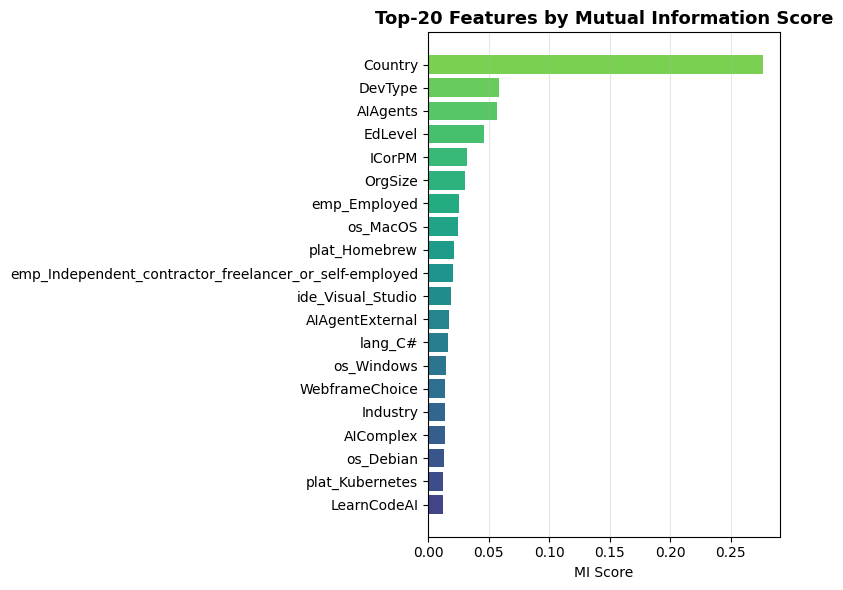


Plot saved → .\feature_selection_results.png


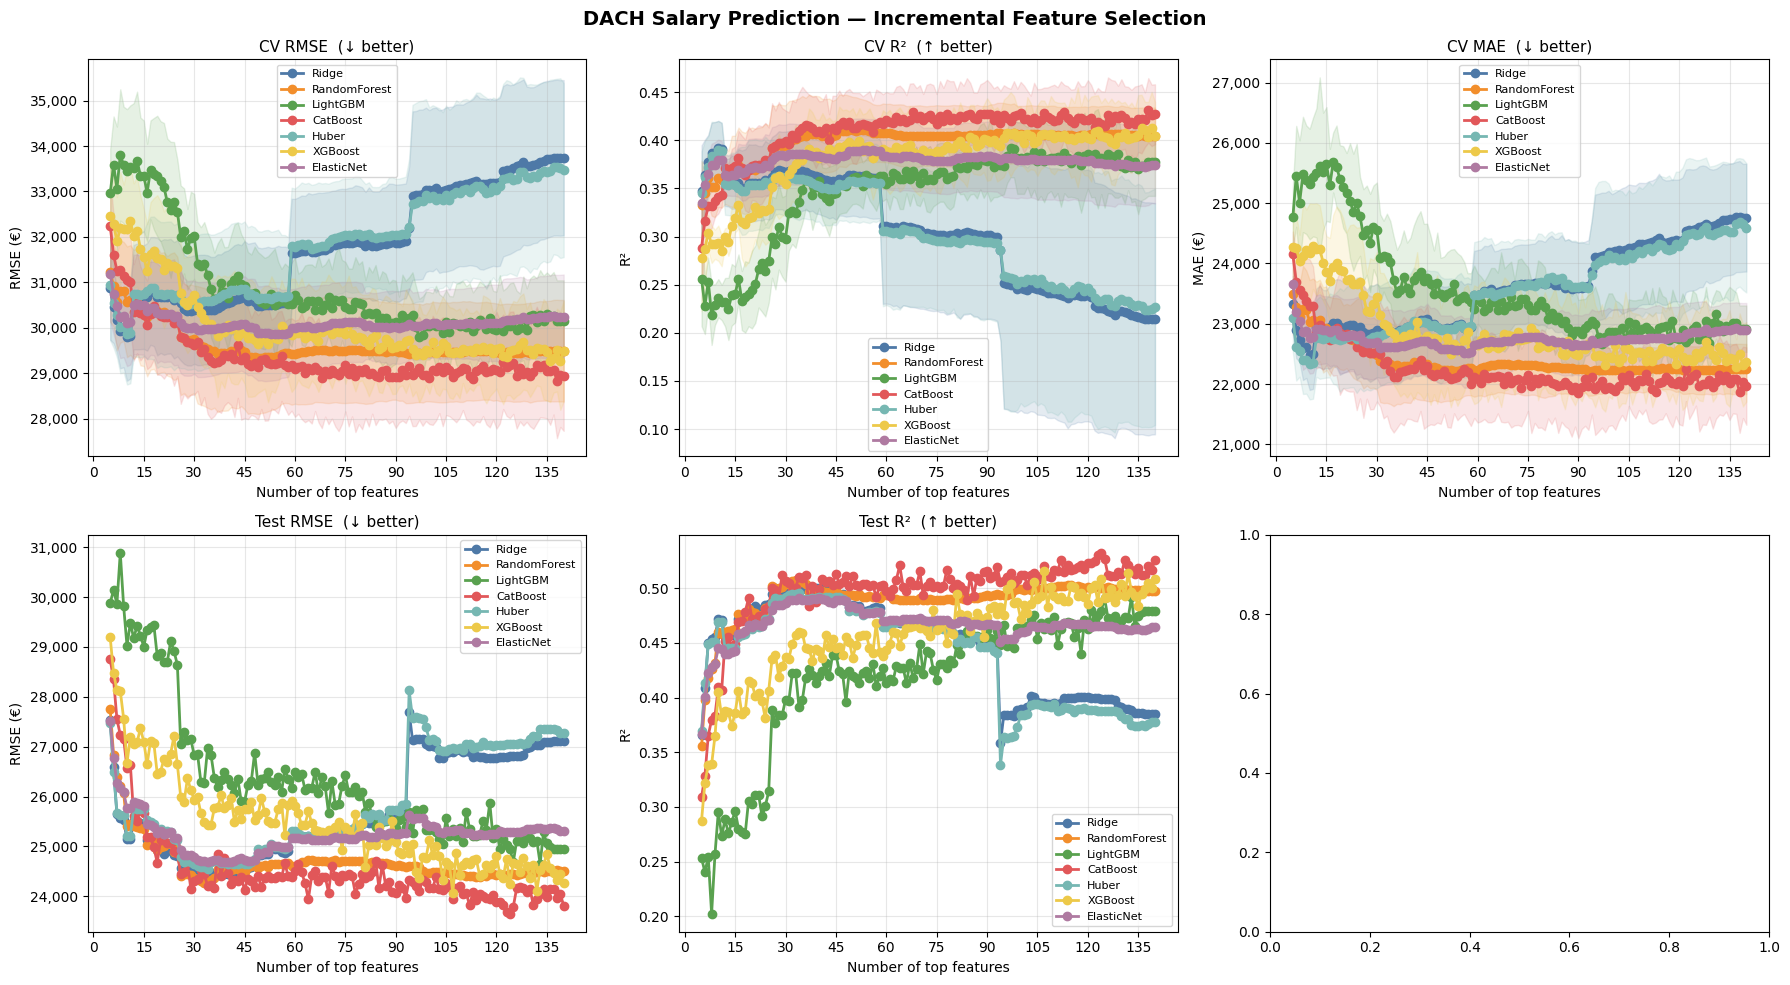


BEST RESULT PER MODEL  (by test R²)
Model             N   CV R²  Test R²    Test RMSE   Test MAE Test MAPE%   Test MedAE
------------------------------------------------------------------------------------
Ridge            34   0.367    0.505       24,339     18,321 
RandomForest     33   0.401    0.507       24,274     18,493 
LightGBM        133   0.372    0.492       24,656     18,465 
CatBoost        124   0.417    0.532       23,652     17,940 
Huber            34   0.360    0.496       24,555     18,387 
XGBoost         107   0.407    0.516       24,063     18,045 
ElasticNet       40   0.383    0.491       24,682     18,687 

Full results saved → .\results_summary.csv


In [44]:
df = load_dach(DATA_PATH)
df = clean_outliers(df)
 
assert SALARY_COL in df.columns, \
    f"Target column '{SALARY_COL}' not found in data. Check SALARY_COL in CONFIG."
assert df[SALARY_COL].notna().all(), \
        "Target column has NaN values — drop or impute them before running."
 
results, mi_scores = run_pipeline(df)
 
plot_mi_scores(mi_scores, top_n=20, output_dir=".")
plot_results(results, output_dir=".")
print_summary(results)

In [45]:
df = load_dach(DATA_PATH)
df = clean_outliers(df)
 
feats = build_features(df)


X = feats.drop(columns=['ConvertedCompYearly'], errors="ignore")
print("X columns:", X.columns.tolist())

y = np.log1p(df['ConvertedCompYearly'])  

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)

X_train_preprocessed = make_preprocessor(X_train).fit_transform(X_train)
print("Shape of preprocessed X_train:", X_train_preprocessed.shape)


pipeline = Pipeline ([
    ('preprocessor',make_preprocessor(X_train)),
    ('model', LinearRegression())
])

kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)


cv_predictions = cross_val_predict(
    pipeline,
    X_train,
    y_train,
    cv=kf
)

y_train_dollars = np.expm1(y_train)
preds_dollars   = np.expm1(cv_predictions)

mae  = mean_absolute_error(y_train_dollars, preds_dollars)
mse = mean_squared_error(y_train_dollars, preds_dollars)
rmse = root_mean_squared_error(y_train_dollars, preds_dollars)
r2   = r2_score(y_train, cv_predictions)   
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

Loaded 49,191 total responses
DACH subset: 3,056 responses
Country
Germany        2322
Switzerland     415
Austria         319
After salary range filter: 2,247 responses
After column drop: 51 columns

Outlier cleaning starting from 2,247 responses:
  Germany       : kept $ 30,483–$218,561  (removed 95 of 1699)
  Austria       : kept $ 27,223–$213,462  (removed 7 of 222)
  Switzerland   : kept $ 69,535–$283,559  (removed 27 of 326)
Built features with 140 columns
X columns: ['LearnCodeAI', 'LearnCodeChoose', 'PurchaseInfluence', 'DatabaseChoice', 'PlatformChoice', 'WebframeChoice', 'DevEnvsChoice', 'AIModelsChoice', 'AISelect', 'AIAgents', 'Country', 'EdLevel', 'DevType', 'OrgSize', 'ICorPM', 'RemoteWork', 'Industry', 'AIThreat', 'LanguageChoice', 'AIComplex', 'AIAgentKnowledge', 'AIAgentOrchestration', 'AIAgentObserveSecure', 'AIAgentExternal', 'lang_JavaScript', 'lang_HTML_CSS', 'lang_SQL', 'lang_Bash_Shell_(all_shells)', 'lang_Python', 'lang_TypeScript', 'lang_Java', 'lang_C#', 'lang